In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

from geoai.utils_ds.PreProcessingOps import PreProcessingOperations
from geoai.utils_ds.VisualizeOps import VisualizeOperations
from geoai.utils_ml.ModelOps import ModelOperations
pre_ops = PreProcessingOperations()
vis_ops = VisualizeOperations()
model_ops = ModelOperations()

In [2]:
X_train = pd.read_csv("csv_files/X_train_fe.csv")
X_test = pd.read_csv("csv_files/X_test_fe.csv")
y_train = pd.read_csv("csv_files/y_train.csv")
y_test = pd.read_csv("csv_files/y_test.csv")
X_train.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_bin_non_veg,NDVI_bin_veg,NDVI_dis_encoded
0,373.5,519.5,389.0,3034.0,1991.0,0.772714,-0.207562,0.002342,139502.25,194033.25,...,4.661945,0.597087,-0.160386,0.001809,0.043082,-0.000486,0.000005,0,1,2


In [3]:
# scale the data
X_train_fe_scaled, X_test_fe_scaled = pre_ops.scale_to_minmax(X_train, X_test)

In [5]:
# apply_pca using 4 components
X_train_pca, X_test_pca = pre_ops.apply_pca(
    X_train_fe_scaled, X_test_fe_scaled, n_components=9
)

# scale the pca data
X_train_pca_scaled, X_test_pca_scaled = pre_ops.scale_to_minmax(X_train_pca, X_test_pca)

# apply_lda using 3 components
X_train_lda, X_test_lda = pre_ops.apply_lda(
    X_train_fe_scaled, y_train, X_test_fe_scaled, n_components=3
)

# scale the lda data
X_train_lda_scaled, X_test_lda_scaled = pre_ops.scale_to_minmax(X_train_lda, X_test_lda)


d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [6]:
X_train_all = pd.concat([X_train_fe_scaled, X_train_pca_scaled, X_train_lda_scaled], axis=1)
X_test_all = pd.concat([X_test_fe_scaled, X_test_pca_scaled, X_test_lda_scaled], axis=1)
X_train_all.head(1)

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,LD_0,LD_1,LD_2
0,0.01238,0.020718,0.023453,0.615321,0.141552,0.941447,0.12174,0.883081,0.001893,0.002796,...,0.181837,0.354272,0.421081,0.566722,0.548849,0.300889,0.574442,0.923739,0.773577,0.488101


In [7]:
important_features, importance_value = model_ops.select_features(X_train_all, y_train)
important_features

['NDVI',
 'LD_2',
 'LD_1',
 'RED NDVI',
 'BLUE NDVI',
 'NIR NDBI',
 'PC_0',
 'BLUE NIR',
 'PC_6',
 'BLUE',
 'SWIR NDVI',
 'NIR',
 'GREEN',
 'RED SWIR',
 'BLUE SWIR',
 'PC_7',
 'LD_0',
 'PC_2',
 'NDBI REI',
 'GREEN NDVI',
 'GREEN REI',
 'NDVI NDBI',
 'SWIR',
 'SWIR REI',
 'NDBI^2',
 'GREEN SWIR',
 'RED NIR',
 'BLUE GREEN',
 'PC_4',
 'REI',
 'PC_3',
 'PC_5',
 'RED',
 'NDBI',
 'NIR SWIR',
 'RED REI',
 'PC_8',
 'GREEN NIR',
 'NDVI REI',
 'PC_1']

In [8]:
print(len(important_features))

40


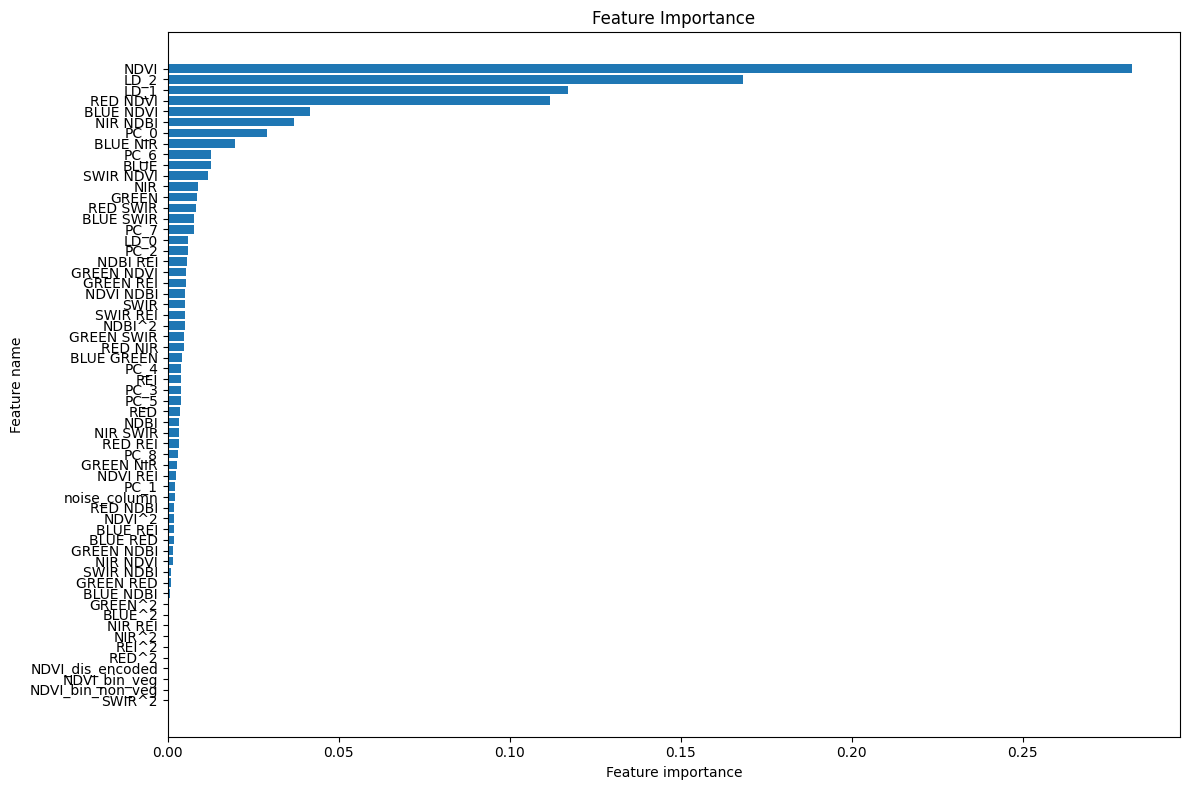

In [9]:
vis_ops.plot_feature_importance(importance_value)

In [10]:
X_train_selected = X_train_all[important_features]
X_test_selected = X_test_all[important_features]
X_train_selected.head(1)

,NDVI,LD_2,LD_1,RED NDVI,BLUE NDVI,NIR NDBI,PC_0,BLUE NIR,PC_6,BLUE,...,PC_3,PC_5,RED,NDBI,NIR SWIR,RED REI,PC_8,GREEN NIR,NDVI REI,PC_1
0,0.941447,0.488101,0.773577,0.639529,0.710866,0.217007,0.915328,0.024107,0.548849,0.01238,...,0.354272,0.566722,0.023453,0.12174,0.200653,0.410421,0.574442,0.03519,0.844985,0.160237


In [11]:
# fit the model using the pca data
lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr.fit(X_train_selected, y_train.values.ravel())

# predict the validation set
y_train_pred = lr.predict(X_train_selected)
y_pred_test = lr.predict(X_test_selected)

# calculate the accuracy
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, y_train_pred)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, y_pred_test)}")

Train Accuracy: (0.9390180878552972, 0.9393549255275683, 0.9390180878552972, 0.939134943082854)
Test Accuracy: (0.9194214876033058, 0.921133618447668, 0.9194214876033058, 0.9198352080038985)


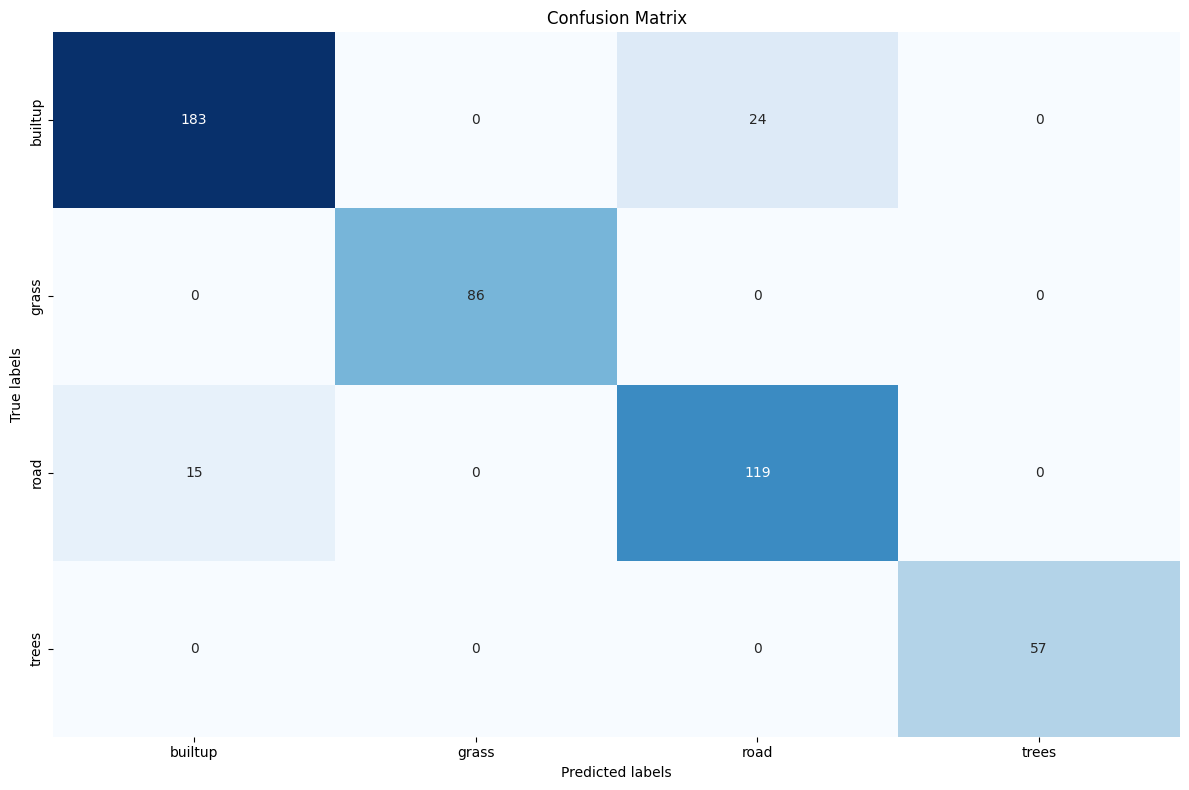

In [12]:
label_mapping = {0: 'builtup', 1: 'grass', 2: 'road', 3: 'trees'}
class_names_str = [label_mapping[label] for label in lr.classes_]
vis_ops.plot_confusion_matrix(y_test, y_pred_test, class_names_str)